# Winoground / Evaluating CLIP — Defensa MCC225
**Niels Victor Pacheco Barrios** · Cuadernos **C5, C8, C10**.

**Tesis:** retrieval alto $\neq$ razonamiento composicional. Reutilizo el motor OpenCLIP del **Cuaderno 10** y evalúo Winoground con los tres scores oficiales.

## 1. Hoja de trazabilidad (entorno de ejecución)

In [1]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name=='notebooks' else pathlib.Path.cwd()
os.chdir(ROOT)            # rutas relativas (data/, outputs/) respecto a la raíz del repo
sys.path.insert(0, str(ROOT))
from src.env_logging import print_snapshot
_ = print_snapshot(ROOT)

/Users/nielspacheco/Desktop/Classes/UNI/Maestria en ciencias Computacion/IA generativa y multimodal/MCC225-ExamenParcial-Winoground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HOJA DE TRAZABILIDAD — ENTORNO DE EJECUCIÓN (MCC225)
           python : 3.12.11
         platform : macOS-26.1-arm64-arm-64bit
     git_revision : 00ac85d
           device : mps (Apple Silicon)
            torch : 2.5.1
  open_clip_torch : 3.3.0
     transformers : 5.12.0
         datasets : 5.0.0
            numpy : 2.1.3
            faiss : 1.14.3


## 2. Datos: Winoground real (gated) o set curado offline
`load_dataset` intenta el benchmark oficial y, si no hay acceso, cae al set curado de pares mínimos composicionales (mismo formato, mismo scorer).

In [2]:
from src.winoground_data import load_dataset
examples, source = load_dataset(prefer_real=True)
print('fuente:', source, '| N =', len(examples))
ex = examples[0]
print('caption_0:', ex.caption_0)
print('caption_1:', ex.caption_1)

fuente: winoground_real | N = 400
caption_0: an old person kisses a young person
caption_1: a young person kisses an old person


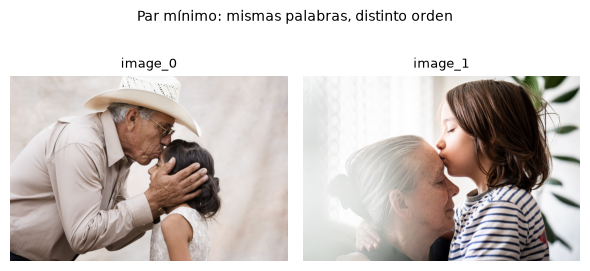

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(ex.image_0); ax[0].set_title('image_0', fontsize=9); ax[0].axis('off')
ax[1].imshow(ex.image_1); ax[1].set_title('image_1', fontsize=9); ax[1].axis('off')
plt.suptitle('Par mínimo: mismas palabras, distinto orden', fontsize=10); plt.tight_layout(); plt.show()

## 3. Celda clave: el scorer de Winoground sobre un par
Codifico las 2 imágenes y 2 captions con OpenCLIP (C10), construyo la matriz $2\times2$ `sim[caption, imagen]` y aplico las definiciones del paper.

In [4]:
from src import openclip_utils as oc
from src.winoground_eval import text_correct, image_correct, group_correct
model, preprocess, tokenizer, device = oc.create_model('ViT-B-32','laion2b_s34b_b79k')
imgf = oc.encode_images(model, preprocess, [ex.image_0, ex.image_1], device)
capf = oc.encode_texts(model, tokenizer, [ex.caption_0, ex.caption_1], device)
sim = capf @ imgf.T   # sim[caption, imagen]
print('matriz 2x2 sim[caption,imagen]:\n', sim.round(3))
print('text=', text_correct(sim), ' image=', image_correct(sim), ' group=', group_correct(sim))

matriz 2x2 sim[caption,imagen]:
 [[0.343 0.329]
 [0.325 0.32 ]]
text= False  image= False  group= False


## 4. Resultado principal (todas las métricas)
Generadas por `scripts/02_run_winoground.py`. Si no existen, ejecútalo primero.

In [5]:
import json, pandas as pd
MET = ROOT/'outputs'/'metrics'
scores = json.loads((MET/'scores.json').read_text())
print('fuente:', scores['source'], '| checkpoint:', scores['primary_checkpoint'])
print(json.dumps(scores['scores'], indent=2))
pd.read_csv(MET/'bootstrap_ci.csv')

fuente: winoground_real | checkpoint: ViT-B-32 / laion2b
{
  "n_examples": 400,
  "text_score": 0.3475,
  "image_score": 0.11,
  "group_score": 0.075,
  "chance_text": 0.25,
  "chance_image": 0.25,
  "chance_group": 0.16666666666666666
}


,metric,mean,lo,hi,rounds,n,chance
0,text,0.3475,0.2999,0.3975,2000,400,0.2500
1,image,0.1100,0.0800,0.1425,2000,400,0.2500
2,group,0.0750,0.0500,0.1025,2000,400,0.1667


In [6]:
pd.read_csv(MET/'checkpoint_comparison.csv')

,label,name,pretrained,n_params_M,text_score,image_score,group_score,seconds
0,ViT-B-32 / laion2b,ViT-B-32,laion2b_s34b_b79k,151.3,0.3475,0.1100,0.0750,0.0
1,ViT-B-16 / datacomp_xl,ViT-B-16,datacomp_xl_s13b_b90k,149.6,0.2975,0.0875,0.0725,0.0
2,ViT-L-14 / openai,ViT-L-14-quickgelu,openai,427.6,0.2875,0.1100,0.0850,0.0


In [7]:
rg = json.loads((MET/'recall_vs_group.json').read_text())
print('Recall texto->imagen:', rg['text_to_image_recall'])
print('group score:', rg['winoground_group_score'], ' (azar', rg['chance_group'], ')')
print('\n=>', rg['note'])

Recall texto->imagen: {'gallery_size': 800, 'R@1': 0.30375, 'R@5': 0.6675, 'R@10': 0.77375, 'median_rank': 2.0, 'mrr': 0.47405691649243326}
group score: 0.075  (azar 0.1667 )

=> Recall@K usa toda la galería (fácil); el group score exige ganar el contraste de pares mínimos (difícil). Alto R@K + bajo group = el retrieval no implica razonamiento composicional.


## 5. Análisis por tag y prueba de ceguera

In [8]:
display(pd.read_csv(MET/'by_tag.csv'))
print(json.dumps(json.loads((MET/'blindness.json').read_text()), indent=2, ensure_ascii=False))

,tag,text,image,group,n
0,Relation,0.304721,0.090129,0.047210,233
1,Object,0.390071,0.106383,0.085106,141
2,Both,0.500000,0.307692,0.269231,26


{
  "real": {
    "n_examples": 400,
    "text_score": 0.3475,
    "image_score": 0.11,
    "group_score": 0.075,
    "chance_text": 0.25,
    "chance_image": 0.25,
    "chance_group": 0.16666666666666666
  },
  "permuted_images": {
    "n_examples": 400,
    "text_score": 0.135,
    "image_score": 0.035,
    "group_score": 0.015,
    "chance_text": 0.25,
    "chance_image": 0.25,
    "chance_group": 0.16666666666666666
  },
  "interpretation": "Si 'real' >> 'permuted_images' (≈ azar), el modelo SÍ usa el contenido de la imagen. Si fueran similares, estaría apoyándose en pistas no visuales."
}


## 6. Figuras

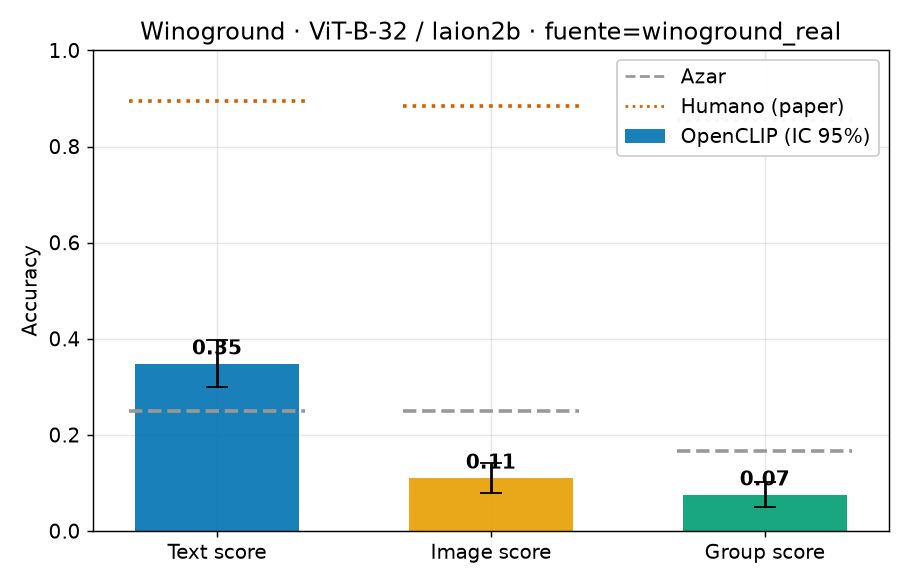

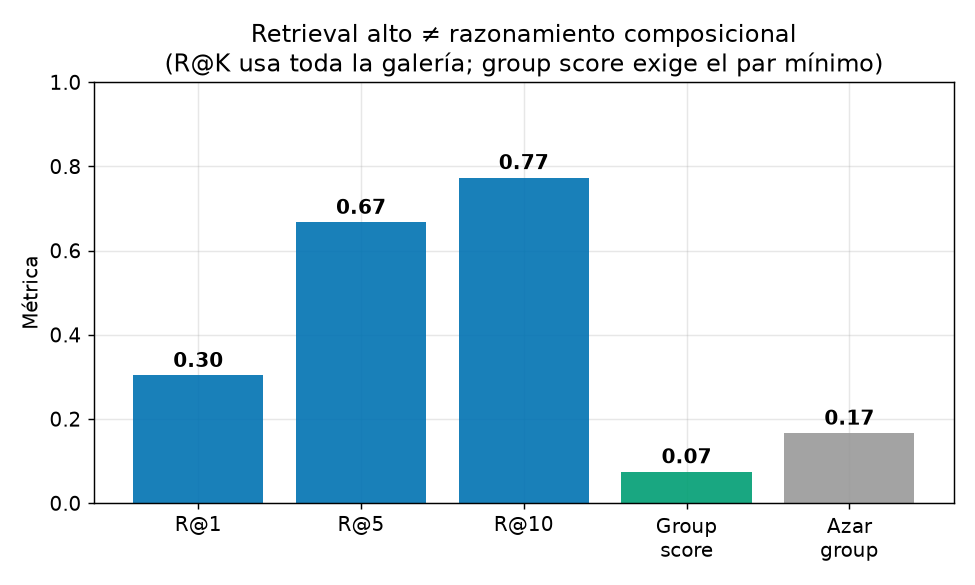

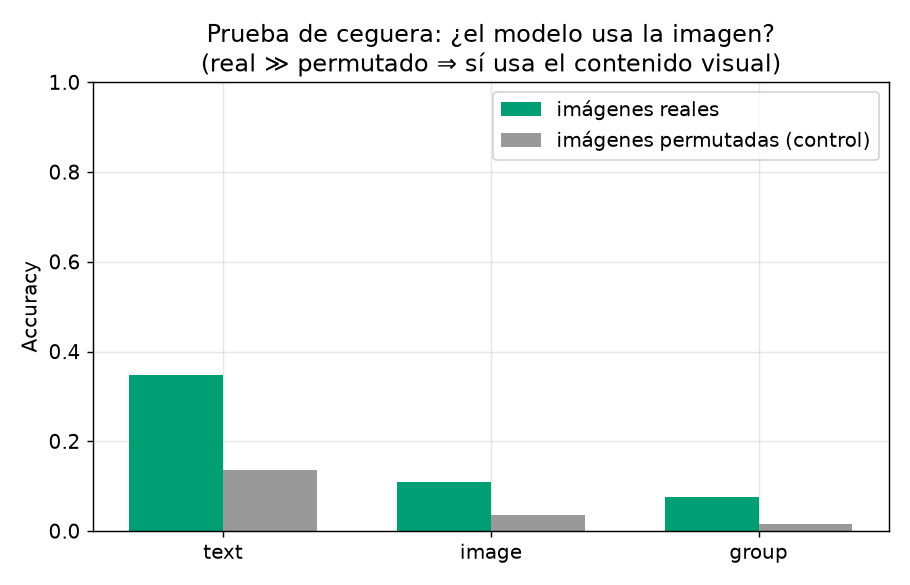

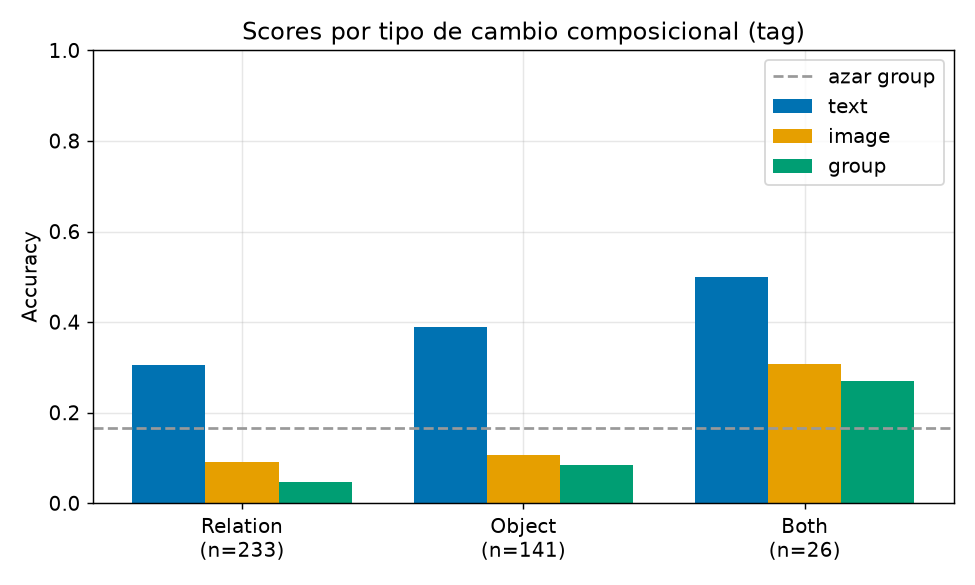

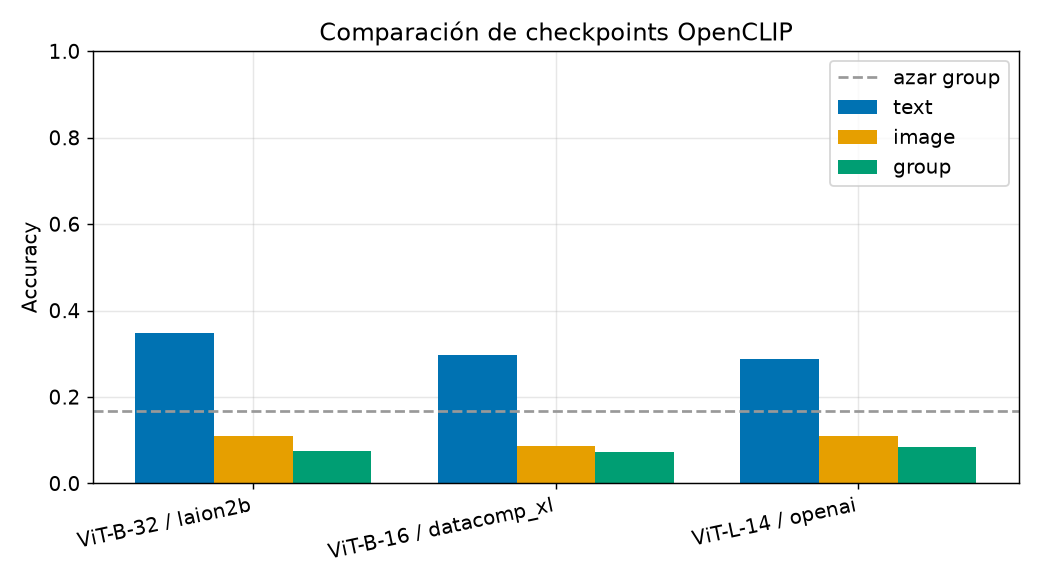

In [9]:
from IPython.display import Image, display
FIG = ROOT/'outputs'/'figures'
for name in ['scores_vs_chance.png','recall_vs_group.png','blindness.png','by_tag.png','checkpoint_comparison.png']:
    p = FIG/name
    if p.exists(): display(Image(filename=str(p)))

## 7. Relación con los cuadernos y limitaciones
- **C10:** motor OpenCLIP (embeddings, coseno, checkpoints, FAISS).
- **C5:** dual-encoder vs fusión profunda — explica *por qué* falla la composición.
- **C8:** atención crossmodal / interpretabilidad — versión interpretable de '¿usa la imagen?'.

**Limitación:** el group score mezcla fallo composicional con ítems ambiguos; el set curado es un proxy. **Mejora:** evaluar un cross-encoder real (C5) y re-ranking con interacción cruzada (C6).